In [20]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction import text
from wordcloud import WordCloud
import warnings, pathlib, re, os, sys
from utils.data import load_data


warnings.filterwarnings("ignore")
plt.rcParams['figure.figsize'] = (10, 6)
random_state = 42


In [2]:
print(pathlib.Path.cwd())

/Users/hunain/d/coding-projects/biodiversity-taxonomy-thesis


In [ ]:

df, df_sample = load_data(sample_n=50000)
print(f'Records: {df.shape[0]:,}, Columns: {df.shape[1]}')
display(df.head())


Loading dataset from local file...
Dataset shape: (359435, 72)
 Count Summary : {'row_count': 359435, 'web_of_science_record_count': np.int64(359435), 'web_of_science_record_distinct_count': 358933, 'duplicated_row_count': np.int64(502)}
Dropped 502 duplicated rows. Remaining rows: 358933
Dropped 16449 rows without Abstract. Remaining rows: 342484
Sampling 1000 rows from the dataset of length 342484.
 51 Columns with null values:
Cited References            342484
Meeting Abstract            342484
Book Group Authors          342461
Book Series Subtitle        342445
Group Authors               342178
Book Author Full Names      342068
Book Authors                342068
Conference Host             341191
Highly Cited Status         340300
Hot Paper Status            340300
Supplement                  340024
Conference Sponsor          339945
Part Number                 339633
Book DOI                    339045
Book Series Title           338975
Book Editors                337976
ISBN  

,Publication Type,Authors,Book Authors,Book Editors,Book Group Authors,Author Full Names,Book Author Full Names,Group Authors,Article Title,Source Title,...,Web of Science Index,Research Areas,IDS Number,Pubmed Id,Open Access Designations,Highly Cited Status,Hot Paper Status,Date of Export,UT (Unique WOS ID),Web of Science Record
4,J,"Rosenberry, CS; Lancia, RA; Conner, MC",NaN,NaN,NaN,"Rosenberry, CS; Lancia, RA; Conner, MC",NaN,NaN,Population effects of white-tailed deer dispersal,WILDLIFE SOCIETY BULLETIN,...,Science Citation Index Expanded (SCI-EXPANDED),Biodiversity & Conservation,264GZ,NaN,NaN,NaN,NaN,2025-07-10,WOS:000084173500041,0
5,J,"Samuel, MD; Takekawa, JY; Samelius, G; Goldber...",NaN,NaN,NaN,"Samuel, MD; Takekawa, JY; Samelius, G; Goldber...",NaN,NaN,Avian cholera mortality in lesser snow geese n...,WILDLIFE SOCIETY BULLETIN,...,Science Citation Index Expanded (SCI-EXPANDED),Biodiversity & Conservation,264GZ,NaN,NaN,NaN,NaN,2025-07-10,WOS:000084173500033,0
7,J,"Stephens, SE; Kaminski, RM; Leopold, BD; Gerar...",NaN,NaN,NaN,"Stephens, SE; Kaminski, RM; Leopold, BD; Gerar...",NaN,NaN,Reproduction of wood ducks in large and small ...,WILDLIFE SOCIETY BULLETIN,...,Science Citation Index Expanded (SCI-EXPANDED),Biodiversity & Conservation,106QZ,NaN,NaN,NaN,NaN,2025-07-10,WOS:000075141500025,0
8,J,"Noyes, JH; Sasser, RG; Johnson, BK; Bryant, LD...",NaN,NaN,NaN,"Noyes, JH; Sasser, RG; Johnson, BK; Bryant, LD...",NaN,NaN,Accuracy of pregnancy detection by serum prote...,WILDLIFE SOCIETY BULLETIN,...,Science Citation Index Expanded (SCI-EXPANDED),Biodiversity & Conservation,YH633,NaN,NaN,NaN,NaN,2025-07-10,WOS:A1997YH63300023,0
12,J,"Yahner, RH; Mahan, CG",NaN,NaN,NaN,"Yahner, RH; Mahan, CG",NaN,NaN,Effects of logging roads on depredation of art...,WILDLIFE SOCIETY BULLETIN,...,Science Citation Index Expanded (SCI-EXPANDED),Biodiversity & Conservation,XA822,NaN,NaN,NaN,NaN,2025-07-10,WOS:A1997XA82200028,0


In [11]:

df['text'] = (df['Article Title'].fillna('') + '. ' + df['Abstract'].fillna(''))
texts = df['text'].astype(str).tolist()
print('Example combined text:', texts[0][:500], '...\n')


Example combined text: Population effects of white-tailed deer dispersal. Dispersal is difficult to measure and is often ignored in population analyses, despite its potential effect on population demographics. We studied population effects of dispersal by estimating natal dispersal, survival, emigration, and immigration of yearling, male while-tailed deer (Odocoileus virginianus) at Chesapeake Farms, Maryland. We radiomarked males to determine natal dispersal and survival and used mark-resight population estimates and ...



Top keywords (all years):
 1. species  (0.0503)
 2. diversity  (0.0208)
 3. biodiversity  (0.0191)
 4. conservation  (0.0190)
 5. forest  (0.0190)
 6. soil  (0.0158)
 7. study  (0.0155)
 8. new  (0.0151)
 9. data  (0.0146)
10. plant  (0.0144)
11. areas  (0.0143)
12. habitat  (0.0142)
13. management  (0.0139)
14. environmental  (0.0138)
15. ecological  (0.0130)
16. climate  (0.0128)
17. population  (0.0127)
18. use  (0.0125)
19. water  (0.0124)
20. ecosystem  (0.0123)
21. change  (0.0122)
22. based  (0.0122)
23. land  (0.0122)
24. community  (0.0119)
25. high  (0.0118)
26. area  (0.0116)
27. communities  (0.0116)
28. results  (0.0115)
29. different  (0.0114)
30. using  (0.0114)


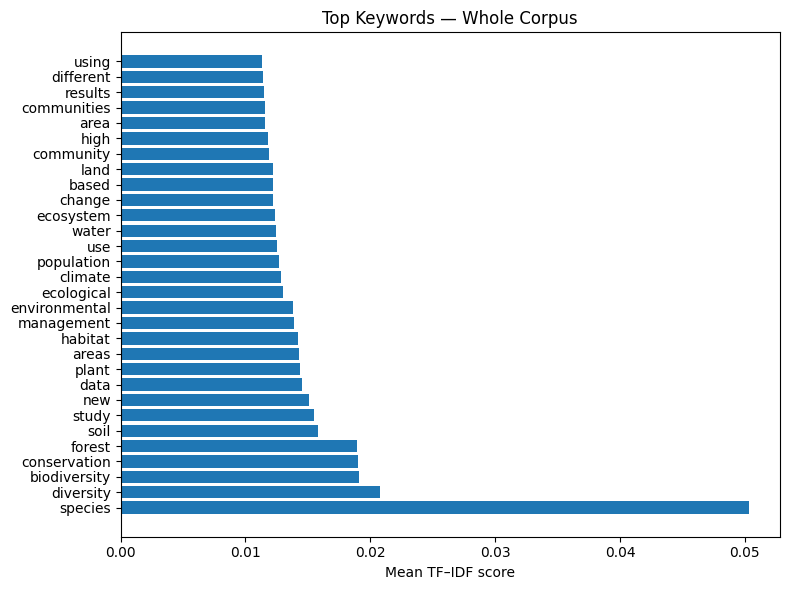

In [ ]:
vectorizer = TfidfVectorizer(stop_words='english',
                             ngram_range=(1,2),
                             max_features=5000,
                             min_df=5)
X = vectorizer.fit_transform(df['text'])
feature_names = np.array(vectorizer.get_feature_names_out())
mean_tfidf = np.asarray(X.mean(axis=0)).ravel()

top_n = 30
top_idx = mean_tfidf.argsort()[::-1][:top_n]

print("Top keywords (all years):")
for rank, idx in enumerate(top_idx, 1):
    print(f"{rank:>2}. {feature_names[idx]}  ({mean_tfidf[idx]:.4f})")

plt.figure(figsize=(8,6))
plt.barh(range(top_n)[::-1], mean_tfidf[top_idx][::-1])
plt.yticks(range(top_n)[::-1], feature_names[top_idx][::-1])
plt.xlabel('Mean TF–IDF score')
plt.title('Top Keywords - Whole Corpus')
plt.tight_layout()
plt.show()


In [24]:
bins = [(1985, 1994), (1995, 2004), (2005, 2014), (2015, 2025)]
labels = [f'{b[0]}–{b[1]}' for b in bins]

def assign_decade(year):
    for (start, end), label in zip(bins, labels):
        if start <= year <= end:
            return label
    return None

df['Decade'] = df['Publication Year'].apply(assign_decade)
df = df.dropna(subset=['Decade'])  # keep rows that fall into our windows
df['Decade'].value_counts().sort_index()


Decade
1985–1994      6467
1995–2004     25771
2005–2014     85625
2015–2025    222761
Name: count, dtype: int64

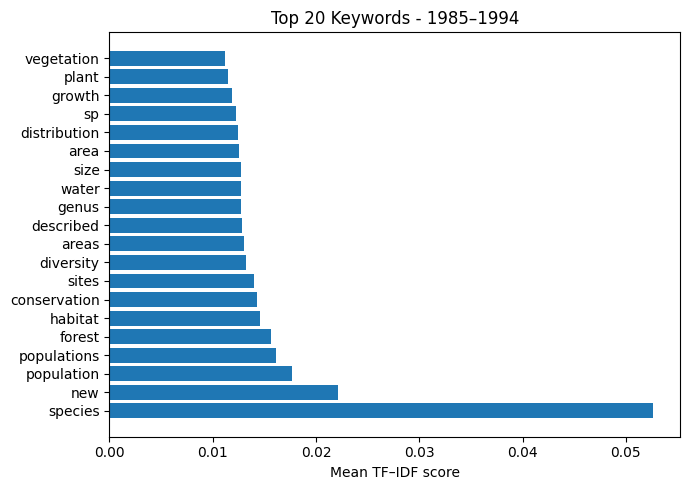

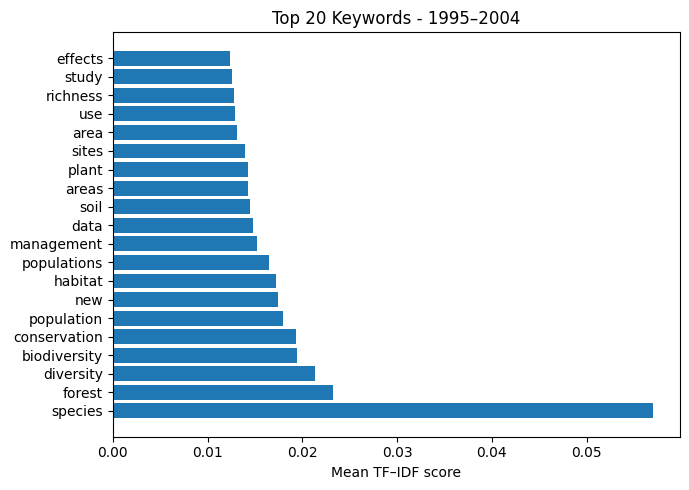

In [ ]:
top_per_decade = {}
n_decade_kw = 20

for decade in labels:
    subset = df[df['Decade'] == decade]
    if subset.empty:
        continue

    vec = TfidfVectorizer(stop_words='english',
                          ngram_range=(1,2),
                          max_features=3000,
                          min_df=3)
    Xm = vec.fit_transform(subset['text'])
    feats = np.array(vec.get_feature_names_out())
    means = np.asarray(Xm.mean(axis=0)).ravel()
    idx = means.argsort()[::-1][:n_decade_kw]
    top_per_decade[decade] = feats[idx]

    # Plot
    plt.figure(figsize=(7,5))
    plt.barh(range(n_decade_kw)[::-1], means[idx][::-1])
    plt.yticks(range(n_decade_kw)[::-1], feats[idx][::-1])
    plt.xlabel('Mean TF–IDF score')
    plt.title(f'Top {n_decade_kw} Keywords - {decade}')
    plt.tight_layout()
    plt.show()

top_per_decade


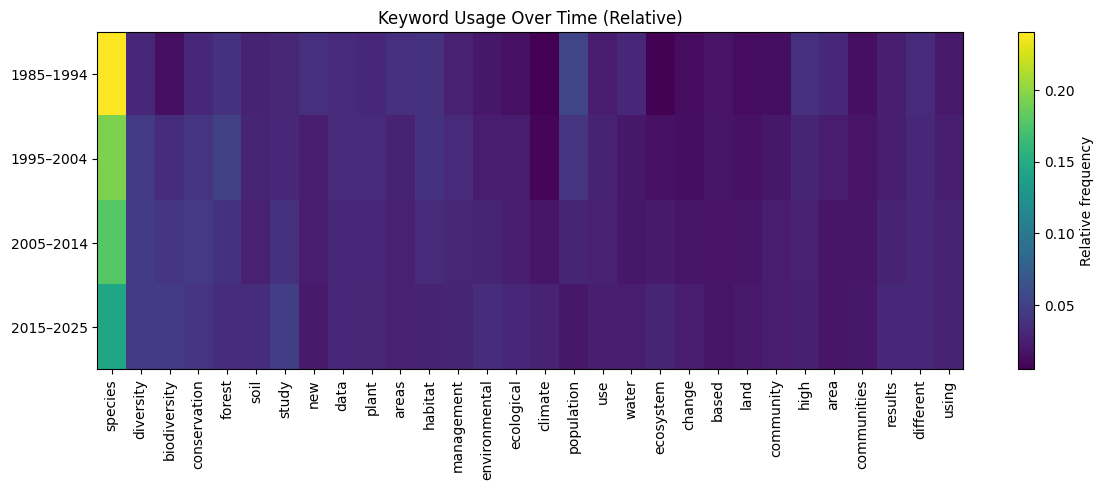

In [27]:
track_terms = feature_names[top_idx][:50]  # union of global top 50
heat = pd.DataFrame(index=labels, columns=track_terms).fillna(0)

for decade in labels:
    rows = df[df['Decade'] == decade]['text']
    for doc in rows:
        for term in track_terms:
            heat.loc[decade, term] += doc.split().count(term)

# Convert to relative freq
heat_rel = heat.div(heat.sum(axis=1), axis=0)

plt.figure(figsize=(12,5))
plt.imshow(heat_rel, aspect='auto')
plt.xticks(range(len(track_terms)), track_terms, rotation=90)
plt.yticks(range(len(labels)), labels)
plt.colorbar(label='Relative frequency')
plt.title('Keyword Usage Over Time (Relative)')
plt.tight_layout()
plt.show()
